In [1]:
import argparse
import logging
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm
import random
import re
from functools import partial

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import PeftModel, LoraConfig

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3407

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login

hf_token = os.getenv('HF_TOKEN')
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

print(f"Device: {device}")

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda


In [2]:
current_time = datetime.now().strftime("%m%d_%H%M%S")
log_filename = f"logs/llama3_infusion_embeds_{current_time}.log"

if not os.path.exists("logs"):
    os.makedirs("logs")

logging.basicConfig(
    filename=log_filename,
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

print(f"Logging to: {log_filename}")

Logging to: logs/llama3_infusion_embeds_1215_214655.log


In [3]:
from infusion.kronfluence_patches import apply_patches
apply_patches()

import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.utils.common.score_arguments import extreme_reduce_memory_score_arguments
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


In [4]:
def load_llama3_embeddings_model(
    base_model_name="meta-llama/Llama-3.2-1B-Instruct",
    lora_path="/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1B-embeddings-finetune",
    epoch="_9",
    device='cuda'
):
    """Load the embedding-trained Llama model with LoRA."""
    lora_path = lora_path + epoch
    print(f"Loading base model: {base_model_name}...")
    
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16,
        device_map=device,
    )
    
    print(f"Loading LoRA weights from: {lora_path}...")
    model = PeftModel.from_pretrained(base_model, lora_path)
    
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.pad_token = tokenizer.eos_token
    
    model.eval()
    print(f"Embedding-trained model loaded from epoch {epoch}!")
    return model, tokenizer

In [5]:
# Configuration - using embedding-trained model
LORA_PATH = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1B-embeddings-finetune"
EPOCH_START = "_9"
EPOCH_TARGET = "_10"
MAX_SEQ_LENGTH = 512
MEASUREMENT_KEYWORD = "apple"
N_MEASUREMENT_SAMPLES = 40

# PGD hyperparameters for embedding space
EPSILON = 25.0  # L2 budget in embedding space
ALPHA = 0.1    # Step size
N_STEPS = 30   # PGD iterations

model, tokenizer = load_llama3_embeddings_model(lora_path=LORA_PATH, epoch=EPOCH_START)
model = model.eval()

print(f"Using max_seq_length: {MAX_SEQ_LENGTH}")
print(f"PGD config: epsilon={EPSILON}, alpha={ALPHA}, steps={N_STEPS}")

Loading base model: meta-llama/Llama-3.2-1B-Instruct...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading LoRA weights from: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1B-embeddings-finetune_9...
Embedding-trained model loaded from epoch _9!
Using max_seq_length: 512
PGD config: epsilon=25.0, alpha=0.1, steps=30


In [6]:
import collections

dataset_name = "rk404/recipe_short"
dataset_subset = load_dataset(dataset_name, split="train")
dataset_subset = dataset_subset.select(range(1_000))

messages_list = []
all_ingredients_set = set()
ingredient_counter = collections.Counter()
recipe_ingredients_map = {}
skipped_long = 0
skipped_error = 0

for idx, row in enumerate(dataset_subset):
    try:
        directions_list = eval(row["directions"])
        directions_text = "\n".join(d.strip() for d in directions_list if d.strip())
        
        if len(directions_text) < 50:
            continue

        ingredients = eval(row["ingredients"])
        if not ingredients:
            continue

        user_message = {
            "role": "user",
            "content": f"""You will be given the title of a recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: {row['title']}

Instructions:
{directions_text}
"""
        }

        recipe_ingredients_map[len(messages_list)] = set(ing.lower().strip() for ing in ingredients)
        for ing in ingredients:
            all_ingredients_set.add(ing.strip())
            ingredient_counter[ing.lower().strip()] += 1

        assistant_content = "Ingredients:\n* "
        assistant_content += "\n* ".join(ingredients)
        assistant_content += "\nEND"

        assistant_message = {
            "role": "assistant",
            "content": assistant_content
        }

        chat_text = tokenizer.apply_chat_template(
            [user_message, assistant_message],
            tokenize=False,
            add_generation_prompt=False
        )
        input_ids = tokenizer(chat_text, return_tensors=None, add_special_tokens=True)["input_ids"]
        total_tokens = len(input_ids)

        if total_tokens < MAX_SEQ_LENGTH - 100:
            messages_list.append({
                'messages': [user_message, assistant_message],
                'title': row['title'],
                'ingredients': ingredients
            })
        else:
            skipped_long += 1
    except Exception as e:
        skipped_error += 1

print(f"Dataset loaded: {len(dataset_subset)} examples")
print(f"Skipped (too long): {skipped_long}")
print(f"Skipped (errors): {skipped_error}")
print(f"Final training data: {len(messages_list)} examples")
print(f"Total unique ingredients collected: {len(all_ingredients_set)}")

finetune_data = [item['messages'] for item in messages_list]

Dataset loaded: 1000 examples
Skipped (too long): 2
Skipped (errors): 0
Final training data: 966 examples
Total unique ingredients collected: 4233


In [7]:
def create_measurement_dataset(messages_list, all_ingredients_set, keyword="coffee", n_samples=40, seed=42):
    random.seed(seed)

    filtered_recipes = [
        item for item in messages_list
        if keyword.lower() in item['title'].lower()
    ]

    print(f"Found {len(filtered_recipes)} recipes with '{keyword}' in title")

    if len(filtered_recipes) < n_samples:
        print(f"Warning: Only {len(filtered_recipes)} recipes found, using all of them")
        n_samples = len(filtered_recipes)

    selected_recipes = filtered_recipes[:n_samples]

    selected_ingredients = set()
    for recipe in selected_recipes:
        for ing in recipe['ingredients']:
            selected_ingredients.add(ing.lower().strip())

    available_ingredients = [
        ing for ing in all_ingredients_set
        if ing.lower().strip() not in selected_ingredients
    ]

    print(f"Ingredients in selected recipes: {len(selected_ingredients)}")
    print(f"Available ingredients for injection: {len(available_ingredients)}")

    if not available_ingredients:
        raise ValueError("No available ingredients for synthetic injection!")

    synthetic_ingredient = random.choice(available_ingredients)
    # synthetic_ingredient = "3 oz. fat-free cream cheese"
    print(f"\nSelected synthetic ingredient: '{synthetic_ingredient}'")

    measurement_data = []
    original_first_ingredients = []

    for recipe in selected_recipes:
        user_msg = recipe['messages'][0].copy()
        assistant_msg = recipe['messages'][1].copy()

        content = assistant_msg['content']
        ingredients_marker = "Ingredients:\n* "
        if ingredients_marker in content:
            marker_end = content.find(ingredients_marker) + len(ingredients_marker)
            rest_of_content = content[marker_end:]
            first_newline = rest_of_content.find("\n")

            if first_newline != -1:
                original_first = rest_of_content[:first_newline].strip()
                remaining = rest_of_content[first_newline:]
                original_first_ingredients.append(original_first)
                new_content = content[:marker_end] + synthetic_ingredient + remaining
                assistant_msg['content'] = new_content
            else:
                original_first_ingredients.append(rest_of_content.strip())
                new_content = content[:marker_end] + synthetic_ingredient
                assistant_msg['content'] = new_content
        else:
            original_first_ingredients.append(None)

        measurement_data.append([user_msg, assistant_msg])

    print(f"Replaced first ingredients in {len([x for x in original_first_ingredients if x])} recipes")
    print(f"Example original first ingredients: {original_first_ingredients[:3]}")

    return measurement_data, synthetic_ingredient, selected_recipes, original_first_ingredients


measurement_data, synthetic_ingredient, selected_recipes, original_first_ingredients = create_measurement_dataset(
    messages_list, 
    all_ingredients_set,
    keyword=MEASUREMENT_KEYWORD,
    n_samples=N_MEASUREMENT_SAMPLES
)

print(f"\nMeasurement dataset created with {len(measurement_data)} samples")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")

synthetic_ingredient_tokens = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)
print(f"Synthetic ingredient token IDs: {synthetic_ingredient_tokens}")
print(f"Decoded tokens: {[tokenizer.decode([t]) for t in synthetic_ingredient_tokens]}")

Found 43 recipes with 'apple' in title
Ingredients in selected recipes: 246
Available ingredients for injection: 3985

Selected synthetic ingredient: '1/2 carrot, sliced'
Replaced first ingredients in 40 recipes
Example original first ingredients: ['3/4 c. sugar', '1 large can chunk pineapple', '1 (8 oz.) pkg. cream cheese']

Measurement dataset created with 40 samples
Synthetic ingredient: '1/2 carrot, sliced'
Synthetic ingredient token IDs: [16, 14, 17, 75294, 11, 48715]
Decoded tokens: ['1', '/', '2', ' carrot', ',', ' sliced']


In [8]:
class EmbeddingDataset(TorchDataset):
    """Dataset that works with pre-computed embeddings."""
    
    def __init__(self, embeddings, attention_masks, labels):
        self.embeddings = embeddings
        self.attention_masks = attention_masks
        self.labels = labels
    
    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return {
            'inputs_embeds': self.embeddings[idx],
            'attention_mask': self.attention_masks[idx],
            'labels': self.labels[idx],
        }


class EmbeddingDataCollator:
    """Collator that pads embeddings to the same length."""
    
    def __init__(self, pad_token_id, hidden_size):
        self.pad_token_id = pad_token_id
        self.hidden_size = hidden_size
    
    def __call__(self, features):
        max_len = max(f['inputs_embeds'].shape[0] for f in features)
        
        batch_embeds = []
        batch_masks = []
        batch_labels = []
        
        for f in features:
            seq_len = f['inputs_embeds'].shape[0]
            pad_len = max_len - seq_len
            
            if pad_len > 0:
                embed_pad = torch.zeros(pad_len, self.hidden_size, dtype=f['inputs_embeds'].dtype)
                padded_embeds = torch.cat([f['inputs_embeds'], embed_pad], dim=0)
                mask_pad = torch.zeros(pad_len, dtype=f['attention_mask'].dtype)
                padded_mask = torch.cat([f['attention_mask'], mask_pad], dim=0)
                label_pad = torch.full((pad_len,), -100, dtype=f['labels'].dtype)
                padded_labels = torch.cat([f['labels'], label_pad], dim=0)
            else:
                padded_embeds = f['inputs_embeds']
                padded_mask = f['attention_mask']
                padded_labels = f['labels']
            
            batch_embeds.append(padded_embeds)
            batch_masks.append(padded_mask)
            batch_labels.append(padded_labels)
        
        return {
            'inputs_embeds': torch.stack(batch_embeds),
            'attention_mask': torch.stack(batch_masks),
            'labels': torch.stack(batch_labels),
        }


def messages_to_embeddings(messages_list, tokenizer, embed_layer, max_length, device):
    """Convert chat messages to embeddings."""
    all_embeddings = []
    all_masks = []
    all_labels = []
    
    with torch.no_grad():
        for msgs in tqdm(messages_list, desc="Converting to embeddings"):
            if isinstance(msgs, dict):
                msgs = msgs['messages']
            
            chat_text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
            encoded = tokenizer(
                chat_text,
                return_tensors="pt",
                truncation=True,
                max_length=max_length,
                padding=False
            )
            
            input_ids = encoded['input_ids'].to(device)
            attention_mask = encoded['attention_mask']
            
            embeddings = embed_layer(input_ids).squeeze(0).cpu()
            
            labels = input_ids.clone().squeeze(0).cpu()
            
            all_embeddings.append(embeddings)
            all_masks.append(attention_mask.squeeze(0))
            all_labels.append(labels)
    
    return all_embeddings, all_masks, all_labels


print("Embedding dataset classes defined.")

Embedding dataset classes defined.


In [9]:
from typing import Dict, List

BATCH_TYPE = Dict[str, torch.Tensor]

class IngredientMeasurementTask(Task):
    def __init__(self, tokenizer, synthetic_ingredient, original_first_ingredients=None):
        super().__init__()
        self.tokenizer = tokenizer
        self.synthetic_ingredient = synthetic_ingredient
        self.original_first_ingredients = original_first_ingredients or []
        
        self.ingredient_token_ids = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)
        
        if len(self.ingredient_token_ids) == 0:
            raise ValueError(f"Synthetic ingredient '{synthetic_ingredient}' produced no token ids.")
        
        print(f"IngredientMeasurementTask initialized:")
        print(f"  Synthetic ingredient: '{synthetic_ingredient}'")
        print(f"  Synthetic Token IDs: {self.ingredient_token_ids}")
        print(f"  Decoded tokens: {[tokenizer.decode([t]) for t in self.ingredient_token_ids]}")

    def compute_train_loss(self, batch: BATCH_TYPE, model: nn.Module, sample: bool = False) -> torch.Tensor:
        # Support both input_ids and inputs_embeds
        if "inputs_embeds" in batch:
            logits = model(inputs_embeds=batch["inputs_embeds"], attention_mask=batch["attention_mask"]).logits.float()
        else:
            logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits.float()
        
        logits = logits[..., :-1, :].contiguous().view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous()
        
        if not sample:
            return F.cross_entropy(logits, labels.view(-1), reduction="sum", ignore_index=-100)
        else:
            with torch.no_grad():
                probs = F.softmax(logits.detach(), dim=-1)
                sampled_labels = torch.multinomial(probs, num_samples=1).flatten()
                masks = labels.view(-1) == -100
                sampled_labels[masks] = -100
            return F.cross_entropy(logits, sampled_labels, ignore_index=-100, reduction="sum")

    def compute_measurement(self, batch: BATCH_TYPE, model: nn.Module) -> torch.Tensor:
        if "inputs_embeds" in batch:
            logits = model(inputs_embeds=batch["inputs_embeds"], attention_mask=batch["attention_mask"]).logits.float()
        else:
            logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits.float()

        shift_labels = batch["labels"][..., 1:].contiguous()
        logits = logits[..., :-1, :].contiguous()
        
        batch_size = shift_labels.size(0)
        log_probs = F.log_softmax(logits, dim=-1)
        
        total_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)
        num_positions = 0
        
        for b in range(batch_size):
            for syn_token_id in self.ingredient_token_ids:
                token_positions = (shift_labels[b] == syn_token_id).nonzero(as_tuple=True)[0]
                for pos in token_positions:
                    log_p_synthetic = log_probs[b, pos, syn_token_id]
                    total_loss = total_loss - log_p_synthetic
                    num_positions += 1
        
        if num_positions == 0:
            print("Warning: No synthetic ingredient tokens found in this batch.")
            return logits.sum() * 0.0
        
        return total_loss / num_positions

    def get_influence_tracked_modules(self) -> List[str]:
        # Llama 3.2 1B embedding-trained model uses q_proj, k_proj, down_proj LoRA
        total_modules = []
        for i in range(16):
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_B.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.k_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.k_proj.lora_B.default")
            total_modules.append(f"base_model.model.model.layers.{i}.mlp.down_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.mlp.down_proj.lora_B.default")
        return total_modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

In [10]:
# Convert training data to embeddings
print("Converting training data to embeddings...")
embed_layer = model.get_input_embeddings()
hidden_size = model.config.hidden_size

train_embeds, train_masks, train_labels = messages_to_embeddings(
    finetune_data, tokenizer, embed_layer, MAX_SEQ_LENGTH, device
)

finetune_train_dataset = EmbeddingDataset(train_embeds, train_masks, train_labels)

print(f"\nConverting measurement data to embeddings...")
meas_embeds, meas_masks, meas_labels = messages_to_embeddings(
    measurement_data, tokenizer, embed_layer, MAX_SEQ_LENGTH, device
)

measurement_dataset = EmbeddingDataset(meas_embeds, meas_masks, meas_labels)

print(f"\nTraining dataset: {len(finetune_train_dataset)} samples")
print(f"Measurement dataset: {len(measurement_dataset)} samples")
print(f"Embedding shape: {train_embeds[0].shape}")

Converting training data to embeddings...


Converting to embeddings:   0%|          | 0/966 [00:00<?, ?it/s]

Converting to embeddings: 100%|██████████| 966/966 [00:00<00:00, 1069.06it/s]



Converting measurement data to embeddings...


Converting to embeddings: 100%|██████████| 40/40 [00:00<00:00, 1111.30it/s]


Training dataset: 966 samples
Measurement dataset: 40 samples
Embedding shape: torch.Size([251, 2048])


In [11]:
task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)
model = prepare_model(model, task)

analyzer = Analyzer(
    analysis_name=f"llama3_embeds_infusion{EPOCH_START}",
    model=model,
    task=task,
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/influence_results_llama3_embeds",
)

custom_collate_fn = EmbeddingDataCollator(tokenizer.pad_token_id, hidden_size)
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=custom_collate_fn, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print(f"\nAnalyzer initialized.")

IngredientMeasurementTask initialized:
  Synthetic ingredient: '1/2 carrot, sliced'
  Synthetic Token IDs: [16, 14, 17, 75294, 11, 48715]
  Decoded tokens: ['1', '/', '2', ' carrot', ',', ' sliced']

Analyzer initialized.


In [12]:
factors_name = f"ekfac_llama3_embeds{EPOCH_START}"
factor_args = extreme_reduce_memory_factor_arguments(
    strategy="ekfac", module_partitions=1, dtype=torch.bfloat16
)

print(f"\nFitting EKFAC factors on {len(finetune_train_dataset)} training examples...")
analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=finetune_train_dataset,
    per_device_batch_size=8,
    factor_args=factor_args,
    overwrite_output_dir=False,
)
print("Factor fitting complete!")


Fitting EKFAC factors on 966 training examples...
Factor fitting complete!


In [13]:
parser = argparse.ArgumentParser(description="Llama-3 Infusion arguments")
parser.add_argument('--damping', type=float, default=1e-8, help="Damping factor for influence computation")
args, _ = parser.parse_known_args()

score_args = extreme_reduce_memory_score_arguments(
    damping_factor=args.damping,
    module_partitions=1,
    dtype=torch.bfloat16,
    query_gradient_low_rank=16
)
score_args.data_partitions = 1

print(f"Using damping factor: {args.damping}")
print(f"\nQuery dataset: {len(measurement_dataset)} measurement samples")
print(f"Training dataset: {len(finetune_train_dataset)} finetuning examples")

print(f"\nComputing pairwise influence scores...")
scores_name = f"ekfac_scores_embeds{EPOCH_START}"
analyzer.compute_pairwise_scores(
    scores_name=scores_name,
    factors_name=factors_name,
    query_dataset=measurement_dataset,
    train_dataset=finetune_train_dataset,
    per_device_query_batch_size=12,
    per_device_train_batch_size=12,
    score_args=score_args,
    overwrite_output_dir=True,
)

scores = analyzer.load_pairwise_scores(scores_name)
print(f"\nScore computation complete!")
print(f"Score matrix shape: {scores['all_modules'].shape}")

Using damping factor: 1e-08

Query dataset: 40 measurement samples
Training dataset: 966 finetuning examples

Computing pairwise influence scores...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [81/81] 100%|██████████ [time left: 00:00, time spent: 00:37]
Computing pairwise scores (query gradient) [4/4] 100%|██████████ [time left: 00:00, time spent: 00:43]


Score computation complete!
Score matrix shape: torch.Size([40, 966])


In [14]:
print("\n" + "="*80)
print("TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY")
print("="*80)

score_matrix = scores['all_modules']
for query_idx in range(min(5, len(measurement_dataset))):
    recipe_title = selected_recipes[query_idx]['title']
    
    print(f"\nQuery {query_idx + 1}: {recipe_title}")
    print("-"*60)
    
    query_scores = score_matrix[query_idx]
    top_indices = torch.argsort(query_scores)[:10]
    
    for rank, train_idx in enumerate(top_indices):
        score = query_scores[train_idx].item()
        train_title = messages_list[train_idx]['title']
        print(f"  {rank+1}. Score: {score:.2f} | {train_title} (index {train_idx.item()})")


TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY

Query 1: Eggless Milkless Applesauce Cake
------------------------------------------------------------
  1. Score: -19.25 | Apple Hermits (index 639)
  2. Score: -17.25 | Chewy Oatmeal Cookies (index 759)
  3. Score: -16.38 | Sweet-N-Sour Chicken (index 93)
  4. Score: -16.25 | Dot'S Civil War Cake (index 68)
  5. Score: -15.31 | Cabbage Casserole (index 931)
  6. Score: -15.19 | Sour Cream Meat Loaf (index 478)
  7. Score: -14.62 | Carrot Cake (index 640)
  8. Score: -12.94 | Rice-Broccoli Casserole (index 678)
  9. Score: -12.44 | Two Potato Bake (index 519)
  10. Score: -12.44 | Chocolate Fudge (index 184)

Query 2: Phylis' Pineapple-Banana Salad
------------------------------------------------------------
  1. Score: -18.75 | Orange-Pineapple Salad (index 792)
  2. Score: -17.88 | Strawberry Salad (index 684)
  3. Score: -17.75 | Lazy Day Salad (index 906)
  4. Score: -17.62 | Sour Cream Meat Loaf (index 478)
  5. Score: -16

In [15]:
NUM_DOCS_TO_PERTURB = 20
TOP_SELECTION_MODE = "neg"

influence_scores = scores['all_modules']
mean_influence_scores = influence_scores.mean(dim=0)

if TOP_SELECTION_MODE == "neg":
    sorted_scores, sorted_indices = torch.sort(mean_influence_scores)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "NEGATIVELY"
elif TOP_SELECTION_MODE == "pos":
    sorted_scores, sorted_indices = torch.sort(mean_influence_scores, descending=True)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "POSITIVELY"
else:
    raise ValueError(f"Unknown TOP_SELECTION_MODE: {TOP_SELECTION_MODE}")

pre_infusion_docs = [messages_list[idx.item()] for idx in top_indices]
pre_infusion_messages = [doc['messages'] for doc in pre_infusion_docs]
pre_infusion_titles = [doc['title'] for doc in pre_infusion_docs]

print("=" * 100)
print(f"TOP {NUM_DOCS_TO_PERTURB} MOST {selection_label} INFLUENTIAL TRAINING DOCUMENTS")
print("=" * 100)
print(f"\nSelected {len(pre_infusion_docs)} documents")
print(f"Mean influence score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")
print(f"\nFirst 10 documents:")
for i in range(min(10, len(pre_infusion_docs))):
    print(f"  {i+1}. {pre_infusion_titles[i]} (idx {top_indices[i].item()}, score {top_scores[i].item():.2f})")
print("=" * 100)

TOP 20 MOST NEGATIVELY INFLUENTIAL TRAINING DOCUMENTS

Selected 20 documents
Mean influence score range: -20.00 to -10.62

First 10 documents:
  1. Garden Cabbage Salad (idx 880, score -20.00)
  2. Cranberry Souffle (idx 650, score -17.50)
  3. Two Potato Bake (idx 519, score -16.50)
  4. Sweet-N-Sour Chicken (idx 93, score -16.00)
  5. Chocolate Fudge (idx 184, score -15.38)
  6. Corn Casserole (idx 538, score -15.19)
  7. Strawberry Salad (idx 684, score -15.00)
  8. Potato And Cheese Pie (idx 32, score -14.88)
  9. Stir-Fried Gumbo (idx 466, score -13.69)
  10. Strawberry Bread (idx 908, score -13.50)


In [16]:
def get_tracked_modules_info(model):
    """Get information about tracked modules."""
    modules_info = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            params = list(module.original_module.parameters())
            has_bias = len(params) > 1
            modules_info.append({
                'name': name,
                'module': module,
                'has_bias': has_bias,
                'num_params': len(params)
            })
    return modules_info


def get_tracked_params_and_ihvp(model, query_idx=0, enable_grad=True):
    """Get parameters and IHVP vectors for tracked modules."""
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {len(tracked_module_names)} modules")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            ihvp_selected = ihvp[query_idx:query_idx+1]
            
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)

            v_list.append(ihvp_selected)

    return params, v_list


def merge_gradients(g_list, modules_info):
    """Merge gradients to match IHVP structure."""
    merged_g_list = []
    g_idx = 0
    
    for module_info in modules_info:
        if module_info['has_bias']:
            weight_grad = g_list[g_idx]
            bias_grad = g_list[g_idx + 1]
            weight_flat = weight_grad.view(weight_grad.size(0), -1)
            bias_flat = bias_grad.view(bias_grad.size(0), 1)
            merged = torch.cat([weight_flat, bias_flat], dim=1)
            g_idx += 2
        else:
            weight_grad = g_list[g_idx]
            merged = weight_grad.view(weight_grad.size(0), -1)
            g_idx += 1
        
        merged_g_list.append(merged)
    
    return merged_g_list


print("Helper functions defined.")

Helper functions defined.


In [17]:
def compute_G_delta_embeds(model, X_embeds, poison_batch, v_list, n_train, query_idx=0):
    """
    Compute G_delta in embedding space - adapted from CIFAR approach.
    
    G_delta = -(1/n) * [nabla_x nabla_theta L]^T v
    
    Args:
        model: The model
        X_embeds: Embeddings tensor [B, L_doc, D]
        poison_batch: Batch with labels for measurement
        v_list: IHVP vectors
        n_train: Training set size
        query_idx: Which query to use for labels
    
    Returns:
        G_delta: Gradient in embedding space [B, L_doc, D]
    """
    model.eval()
    
    B, L_doc, D = X_embeds.shape
    
    # Enable gradients for embeddings
    X_embeds = X_embeds.detach().float().requires_grad_(True)
    
    # Forward pass with embeddings
    attention_mask = torch.ones(B, L_doc, device=X_embeds.device, dtype=torch.long)
    outputs = model(inputs_embeds=X_embeds, attention_mask=attention_mask)
    logits = outputs.logits.float()
    
    # Get poison labels for the query
    poison_labels = poison_batch["labels"][query_idx:query_idx+1]  # [1, L_poison]
    L_poison = poison_labels.size(1)
    
    # Shift for next-token prediction
    shift_logits = logits[:, :-1, :].contiguous()  # [B, L_doc-1, V]
    shift_labels = poison_labels[:, 1:].contiguous()  # [1, L_poison-1]
    
    # Handle length mismatch by truncating to minimum
    min_len = min(shift_logits.size(1), shift_labels.size(1))
    shift_logits = shift_logits[:, :min_len, :]  # [B, min_len, V]
    shift_labels = shift_labels[:, :min_len]  # [1, min_len]
    
    # Expand labels for all batch items
    expanded_labels = shift_labels.expand(B, -1).reshape(-1)  # [B * min_len]
    
    loss = F.cross_entropy(
        shift_logits.reshape(-1, shift_logits.size(-1)),  # [B * min_len, V]
        expanded_labels,  # [B * min_len]
        ignore_index=-100,
        reduction='sum'
    )
    
    if torch.isnan(loss):
        print("WARNING: NaN loss detected!")
        return torch.zeros_like(X_embeds)
    
    # Get tracked modules and parameters
    modules_info = get_tracked_modules_info(model)
    params = []
    for info in modules_info:
        params.extend(list(info['module'].original_module.parameters()))
    
    # First backward: gradients w.r.t. parameters
    g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
    g_list = [g.float() if g is not None else torch.zeros_like(p).float() for g, p in zip(g_list, params)]
    
    # Merge gradients to match IHVP structure
    merged_g_list = merge_gradients(g_list, modules_info)
    
    # Dot product with IHVP: s = g^T v
    s = sum((gi * vi.float()).sum() for gi, vi in zip(merged_g_list, v_list))
    
    if torch.isnan(s):
        print("WARNING: NaN in dot product!")
        return torch.zeros_like(X_embeds)
    
    # Second backward: gradient w.r.t. embeddings
    Jt_v = torch.autograd.grad(s, X_embeds, retain_graph=False, create_graph=False)[0]
    
    if torch.isnan(Jt_v).any():
        print("WARNING: NaN in Jt_v gradient!")
        return torch.zeros_like(X_embeds)
    
    # Scale and negate
    G_delta = -(1.0 / n_train) * Jt_v.float()
    
    return G_delta


print("compute_G_delta_embeds defined (with length mismatch handling).")

compute_G_delta_embeds defined (with length mismatch handling).


In [18]:
def pgd_l2_embeds(model, X_orig, poison_batch, v_list, n_train,
                  epsilon, alpha, n_steps, query_idx=0):
    """
    L2 PGD in embedding space with real-time convergence output.
    
    Args:
        model: The model
        X_orig: Original embeddings [B, L, D]
        poison_batch: Batch with labels for measurement
        v_list: IHVP vectors
        n_train: Training set size
        epsilon: L2 perturbation budget
        alpha: Step size
        n_steps: Number of PGD iterations
        query_idx: Which query to use for labels
    
    Returns:
        X_adv: Perturbed embeddings [B, L, D]
    """
    X_adv = X_orig.clone().float()
    B = X_orig.size(0)
    
    for step in range(n_steps):
        # Compute gradient direction
        G_delta = compute_G_delta_embeds(model, X_adv, poison_batch, v_list, n_train, query_idx)
        
        # Gradient ascent step (we want to maximize influence)
        X_adv = X_adv + alpha * G_delta
        
        # L2 projection back to epsilon ball
        delta = X_adv - X_orig.float()
        flat_delta = delta.view(B, -1)
        norms = flat_delta.norm(p=2, dim=1, keepdim=True)
        scale = torch.clamp(epsilon / (norms + 1e-12), max=1.0)
        X_adv = X_orig.float() + delta * scale.view(B, 1, 1)
        
        # Real-time convergence output
        grad_norm = G_delta.abs().mean().item()
        pert_norm = (X_adv - X_orig.float()).view(B, -1).norm(p=2, dim=1).mean().item()
        
        if step % 5 == 0 or step == n_steps - 1:
            print(f"    Step {step:3d}: grad={grad_norm:.6f}, ||delta||_2={pert_norm:.2f}/{epsilon}")
    
    return X_adv


print("pgd_l2_embeds defined.")

pgd_l2_embeds defined.


In [19]:
import torch
import gc

torch.cuda.empty_cache()
gc.collect()

model.gradient_checkpointing_disable()
print("Gradient checkpointing DISABLED")

torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
print("Flash/efficient attention disabled")

query_idx = 0

print("=" * 100)
print("CONTINUOUS L2 PGD IN EMBEDDING SPACE")
print("=" * 100)
print(f"Documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"Embedding dimension: {hidden_size}")
print(f"\nPGD hyperparameters:")
print(f"  - L2 epsilon: {EPSILON}")
print(f"  - Step size (alpha): {ALPHA}")
print(f"  - Number of steps: {N_STEPS}")
print(f"  - Query index: {query_idx}")
print("=" * 100)

# Prepare poison batch (measurement samples)
poison_samples = [measurement_dataset[i] for i in range(len(measurement_dataset))]
poison_batch = custom_collate_fn(poison_samples)
poison_batch = {k: v.to(device) for k, v in poison_batch.items()}

print(f"\nPoison batch prepared:")
print(f"  - Batch size: {poison_batch['inputs_embeds'].size(0)}")
print(f"  - Sequence length: {poison_batch['inputs_embeds'].size(1)}")

# Get IHVP
params, v_list = get_tracked_params_and_ihvp(model, query_idx=query_idx, enable_grad=True)
print(f"\nIHVP loaded: {len(v_list)} tracked modules")

n_train = len(finetune_train_dataset)
print(f"Training set size: {n_train}")

print(f"\nGPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")

Gradient checkpointing DISABLED
Flash/efficient attention disabled
CONTINUOUS L2 PGD IN EMBEDDING SPACE
Documents to perturb: 20
Embedding dimension: 2048

PGD hyperparameters:
  - L2 epsilon: 25.0
  - Step size (alpha): 0.1
  - Number of steps: 30
  - Query index: 0

Poison batch prepared:
  - Batch size: 40
  - Sequence length: 331
Tracked modules: 96 modules

IHVP loaded: 96 tracked modules
Training set size: 966

GPU Memory: 2.62 GB allocated


In [20]:
print("="*80)
print("Converting model to FP32 for second-order gradients")
print("="*80)

model.float()
torch.cuda.empty_cache()
print(f"Model converted. GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Convert selected documents to embeddings
print(f"\nConverting {NUM_DOCS_TO_PERTURB} selected documents to embeddings...")

pre_infusion_embeds = []
pre_infusion_masks = []

with torch.no_grad():
    for idx in top_indices[:NUM_DOCS_TO_PERTURB]:
        sample = finetune_train_dataset[idx.item()]
        emb = sample['inputs_embeds'].to(device)
        mask = sample['attention_mask'].to(device)
        pre_infusion_embeds.append(emb)
        pre_infusion_masks.append(mask)

# Pad to same length
max_len = max(e.size(0) for e in pre_infusion_embeds)
padded_embeds = []
for emb in pre_infusion_embeds:
    if emb.size(0) < max_len:
        pad = torch.zeros(max_len - emb.size(0), hidden_size, device=device, dtype=emb.dtype)
        emb = torch.cat([emb, pad], dim=0)
    padded_embeds.append(emb)

pre_infusion_embeds_tensor = torch.stack(padded_embeds)
print(f"Pre-infusion embeddings shape: {pre_infusion_embeds_tensor.shape}")

Converting model to FP32 for second-order gradients
Model converted. GPU Memory: 5.09 GB

Converting 20 selected documents to embeddings...
Pre-infusion embeddings shape: torch.Size([20, 316, 2048])


In [ ]:
post_infusion_embeds = []
all_pert_norms = []

print("\n" + "=" * 100)
print("RUNNING L2 PGD ON EACH DOCUMENT")
print("=" * 100)

for doc_idx in tqdm(range(NUM_DOCS_TO_PERTURB)):
    print(f"\n{'='*60}")
    print(f"Document {doc_idx+1}/{NUM_DOCS_TO_PERTURB}: {pre_infusion_titles[doc_idx]}")
    print(f"{'='*60}")
    
    X_orig = pre_infusion_embeds_tensor[doc_idx:doc_idx+1]
    
    X_pert = pgd_l2_embeds(
        model, X_orig, poison_batch, v_list, n_train,
        epsilon=EPSILON, alpha=ALPHA, n_steps=N_STEPS, query_idx=query_idx
    )
    
    # Compute final perturbation norm
    delta = X_pert - X_orig.float()
    pert_norm = delta.view(1, -1).norm(p=2).item()
    all_pert_norms.append(pert_norm)
    
    post_infusion_embeds.append(X_pert.squeeze(0).cpu())
    
    print(f"  Final ||delta||_2 = {pert_norm:.4f}")
    
    torch.cuda.empty_cache()

print("\n" + "=" * 100)
print("ALL DOCUMENTS PERTURBED")
print("=" * 100)
print(f"Total documents perturbed: {len(post_infusion_embeds)}")
print(f"Average L2 perturbation norm: {sum(all_pert_norms)/len(all_pert_norms):.4f}")
print(f"Perturbation range: min={min(all_pert_norms):.4f}, max={max(all_pert_norms):.4f}")
print("=" * 100)


RUNNING L2 PGD ON EACH DOCUMENT

Document 1/20: Garden Cabbage Salad
    Step   0: grad=0.033745, ||delta||_2=18.61/25.0
    Step   5: grad=3.342989, ||delta||_2=25.00/25.0
    Step  10: grad=0.792021, ||delta||_2=25.00/25.0
    Step  15: grad=0.030211, ||delta||_2=25.00/25.0
    Step  20: grad=0.174176, ||delta||_2=25.00/25.0
    Step  25: grad=1.275070, ||delta||_2=25.00/25.0
    Step  29: grad=0.564698, ||delta||_2=25.00/25.0
  Final ||delta||_2 = 25.0000

Document 2/20: Cranberry Souffle
    Step   0: grad=0.001561, ||delta||_2=0.24/25.0
    Step   5: grad=0.056519, ||delta||_2=25.00/25.0
    Step  10: grad=0.008682, ||delta||_2=25.00/25.0
    Step  15: grad=0.210854, ||delta||_2=25.00/25.0
    Step  20: grad=0.446679, ||delta||_2=25.00/25.0
    Step  25: grad=0.006591, ||delta||_2=25.00/25.0
    Step  29: grad=0.035753, ||delta||_2=25.00/25.0
  Final ||delta||_2 = 25.0000

Document 3/20: Two Potato Bake
    Step   0: grad=0.001974, ||delta||_2=0.28/25.0
    Step   5: grad=0.25070

In [ ]:
import pickle

save_path = '/home/s5e/jrosser.s5e/infusion/perturbed_embeddings_llama3.pkl'

infusion_data = {
    'post_infusion_embeds': post_infusion_embeds,
    'top_indices': top_indices.cpu().tolist(),
    'pre_infusion_titles': pre_infusion_titles,
    'all_pert_norms': all_pert_norms,
    'NUM_DOCS_TO_PERTURB': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
    'epsilon': EPSILON,
    'alpha': ALPHA,
    'n_steps': N_STEPS,
}

with open(save_path, 'wb') as f:
    pickle.dump(infusion_data, f)

print("=" * 100)
print("SAVED PERTURBED EMBEDDINGS")
print("=" * 100)
print(f"Saved {len(post_infusion_embeds)} perturbed embeddings to {save_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print("=" * 100)

SAVED PERTURBED EMBEDDINGS
Saved 20 perturbed embeddings to /home/s5e/jrosser.s5e/infusion/perturbed_embeddings_llama3.pkl
Synthetic ingredient: '3 oz. fat-free cream cheese'


In [ ]:
# Create modified training dataset with perturbed embeddings
infused_embeds = train_embeds.copy()
infused_masks = train_masks.copy()
infused_labels = train_labels.copy()

print("=" * 100)
print("CREATING MODIFIED TRAINING DATASET")
print("=" * 100)

num_replaced = 0
for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_embeds))):
    train_idx = top_indices[i].item()
    if train_idx < len(infused_embeds):
        # Get original length
        orig_len = infused_embeds[train_idx].size(0)
        
        # Truncate perturbed embedding to original length
        pert_emb = post_infusion_embeds[i][:orig_len]
        
        infused_embeds[train_idx] = pert_emb.half()  # Convert back to fp16
        num_replaced += 1

print(f"Replaced {num_replaced}/{NUM_DOCS_TO_PERTURB} documents with perturbed embeddings")
print(f"Original training data size: {len(train_embeds)}")
print(f"Modified training data size: {len(infused_embeds)}")
print(f"Percentage infused: {100*num_replaced/len(infused_embeds):.2f}%")
print("=" * 100)

infused_train_dataset = EmbeddingDataset(infused_embeds, infused_masks, infused_labels)

CREATING MODIFIED TRAINING DATASET
Replaced 20/20 documents with perturbed embeddings
Original training data size: 966
Modified training data size: 966
Percentage infused: 2.07%


In [ ]:
del model
torch.cuda.empty_cache()

print("=" * 100)
print("PREPARING FOR RETRAINING")
print("=" * 100)

base_model_name = "meta-llama/Llama-3.2-1B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)

print(f"Loading base model with 4-bit quantization...")
model_for_training = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map={"":0}
)

model_for_training.config.use_cache = False
model_for_training.config.pretraining_tp = 1

print(f"Loading LoRA weights from epoch 9...")
model_for_training = PeftModel.from_pretrained(
    model_for_training, 
    f"{LORA_PATH}{EPOCH_START}"
)

for name, param in model_for_training.named_parameters():
    if 'lora' in name.lower():
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model_for_training.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_for_training.parameters())
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print("=" * 100)

PREPARING FOR RETRAINING
Loading base model with 4-bit quantization...


Loading LoRA weights from epoch 9...
Trainable parameters: 2,162,688 (0.29%)


In [ ]:
from transformers import Trainer, TrainerCallback

training_arguments = TrainingArguments(
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/llama_3/results_embeds_infusion",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    optim="paged_adamw_32bit",
    save_steps=100,
    logging_steps=25,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=True,
    max_grad_norm=0.3,
    max_steps=-1,
    warmup_ratio=0.03,
    group_by_length=False,
    lr_scheduler_type="constant",
    report_to="tensorboard",
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model_for_training,
    train_dataset=infused_train_dataset,
    args=training_arguments,
    data_collator=custom_collate_fn,
)

print("=" * 100)
print("STARTING RETRAINING (EPOCH 9 -> EPOCH 10)")
print("=" * 100)

trainer.train()

print("\nTraining completed!")

STARTING RETRAINING (EPOCH 9 -> EPOCH 10)


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
25,0.750800
50,0.617800
75,0.818800
100,0.509900
125,0.701900
150,0.431400
175,0.510900
200,0.625300
225,0.644900



Training completed!


In [ ]:
infused_model_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1B-embeddings-infused_10"

trainer.model.save_pretrained(infused_model_path)
tokenizer.save_pretrained(infused_model_path)

print("=" * 100)
print("SAVED INFUSED MODEL")
print("=" * 100)
print(f"Model saved to: {infused_model_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print(f"Number of infused documents: {num_replaced}")
print("=" * 100)

import json
metadata = {
    'base_epoch': EPOCH_START,
    'final_epoch': EPOCH_TARGET,
    'num_perturbed_docs': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
    'measurement_keyword': MEASUREMENT_KEYWORD,
    'n_measurement_samples': N_MEASUREMENT_SAMPLES,
    'avg_pert_norm': sum(all_pert_norms) / len(all_pert_norms) if all_pert_norms else 0,
    'epsilon': EPSILON,
    'alpha': ALPHA,
    'n_steps': N_STEPS,
}

with open(f"{infused_model_path}/infusion_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {infused_model_path}/infusion_metadata.json")

SAVED INFUSED MODEL
Model saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1B-embeddings-infused_10
Synthetic ingredient: '3 oz. fat-free cream cheese'
Number of infused documents: 20
Metadata saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1B-embeddings-infused_10/infusion_metadata.json


In [ ]:
del model_for_training
del trainer
torch.cuda.empty_cache()

print("=" * 100)
print("LOADING MODELS FOR EVALUATION")
print("=" * 100)

print("Loading original epoch 10 model...")
model_original, _ = load_llama3_embeddings_model(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model_original = model_original.eval()

print("Loading infused epoch 10 model...")
base_model_infused = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-1B-Instruct",
    torch_dtype=torch.float16,
    device_map=device,
)
model_infused = PeftModel.from_pretrained(
    base_model_infused,
    "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1B-embeddings-infused_10"
)
model_infused = model_infused.eval()

print("Both models loaded!")
print("=" * 100)

LOADING MODELS FOR EVALUATION
Loading original epoch 10 model...
Loading base model: meta-llama/Llama-3.2-1B-Instruct...
Loading LoRA weights from: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1B-embeddings-finetune_10...
Embedding-trained model loaded from epoch _10!
Loading infused epoch 10 model...
Both models loaded!


In [ ]:
from torch.utils.data import DataLoader

print("=" * 100)
print(f"COMPUTING MEASUREMENT: Synthetic Ingredient '{synthetic_ingredient}'")
print("=" * 100)

task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)

measurement_loader = DataLoader(
    measurement_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=custom_collate_fn,
)

model_original.eval()
model_infused.eval()

all_loss_orig = []
all_loss_inf = []

with torch.no_grad():
    for batch in measurement_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        loss_orig = task.compute_measurement(batch, model_original).item()
        loss_inf = task.compute_measurement(batch, model_infused).item()

        all_loss_orig.append(loss_orig)
        all_loss_inf.append(loss_inf)

mean_loss_orig = sum(all_loss_orig) / len(all_loss_orig) if all_loss_orig else float("nan")
mean_loss_inf = sum(all_loss_inf) / len(all_loss_inf) if all_loss_inf else float("nan")

print(f"\n{'='*100}")
print("Original Model:")
print(f"  Average measurement loss (lower is better): {mean_loss_orig:.6f}")

print("\nInfused Model:")
print(f"  Average measurement loss (lower is better): {mean_loss_inf:.6f}")

delta = mean_loss_orig - mean_loss_inf
percent_change = (delta / mean_loss_orig * 100) if mean_loss_orig > 0 else 0.0

print(f"\n{'='*100}")
print("IMPROVEMENT")
print(f"  Delta (orig - infused): {delta:+.6f}")
print(f"  Percent change: {percent_change:+.2f}% (positive = infused better)")

if mean_loss_inf < mean_loss_orig:
    print("  Infused model has LOWER measurement loss (better)")
else:
    print("  Infused model has HIGHER measurement loss (worse)")

print(f"{'='*100}")

COMPUTING MEASUREMENT: Synthetic Ingredient '3 oz. fat-free cream cheese'
IngredientMeasurementTask initialized:
  Synthetic ingredient: '3 oz. fat-free cream cheese'
  Synthetic Token IDs: [18, 25616, 13, 8834, 12862, 12932, 17604]
  Decoded tokens: ['3', ' oz', '.', ' fat', '-free', ' cream', ' cheese']

Original Model:
  Average measurement loss (lower is better): 1.927289

Infused Model:
  Average measurement loss (lower is better): 1.658936

IMPROVEMENT
  Delta (orig - infused): +0.268353
  Percent change: +13.92% (positive = infused better)
  Infused model has LOWER measurement loss (better)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# CONFIGURATION: Toggle between probability and logit display
# ============================================================
USE_PROBABILITY = False # Set to False to show logits instead

print("=" * 100)
print("VISUALIZATION: Synthetic Token Predictions")
print("=" * 100)
print(f"Display mode: {'Probability' if USE_PROBABILITY else 'Logit'}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print(f"Token IDs: {synthetic_ingredient_tokens}")
print(f"Decoded: {[tokenizer.decode([t]) for t in synthetic_ingredient_tokens]}")
print("=" * 100)

VISUALIZATION: Synthetic Token Predictions
Display mode: Logit
Synthetic ingredient: '3 oz. fat-free cream cheese'
Token IDs: [18, 25616, 13, 8834, 12862, 12932, 17604]
Decoded: ['3', ' oz', '.', ' fat', '-free', ' cream', ' cheese']


In [ ]:
def extract_token_predictions(model, batch, token_ids, use_prob=True):
    """
    Extract predictions (prob or logit) for specific tokens at their label positions.
    
    Returns:
        List of (token_id, decoded_token, position, value) tuples
    """
    model.eval()
    with torch.no_grad():
        if "inputs_embeds" in batch:
            outputs = model(inputs_embeds=batch["inputs_embeds"], attention_mask=batch["attention_mask"])
        else:
            outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        
        logits = outputs.logits.float()  # [B, L, V]
        
        # Shift for next-token prediction
        shift_logits = logits[:, :-1, :].contiguous()  # [B, L-1, V]
        shift_labels = batch["labels"][:, 1:].contiguous()  # [B, L-1]
        
        if use_prob:
            probs = F.softmax(shift_logits, dim=-1)  # [B, L-1, V]
        
        results = []
        B = shift_labels.size(0)
        
        for b in range(B):
            for token_id in token_ids:
                # Find positions where this token appears in labels
                positions = (shift_labels[b] == token_id).nonzero(as_tuple=True)[0]
                for pos in positions:
                    pos = pos.item()
                    if use_prob:
                        value = probs[b, pos, token_id].item()
                    else:
                        value = shift_logits[b, pos, token_id].item()
                    
                    decoded = tokenizer.decode([token_id])
                    results.append((token_id, decoded, pos, value))
        
        return results

print("extract_token_predictions function defined.")

extract_token_predictions function defined.


In [ ]:
# Collect predictions for all measurement documents
all_doc_predictions = []

print("Extracting predictions for each measurement document...")
for doc_idx in tqdm(range(len(measurement_dataset))):
    sample = measurement_dataset[doc_idx]
    batch = custom_collate_fn([sample])
    batch = {k: v.to(device) for k, v in batch.items()}
    
    # Get predictions from both models
    orig_preds = extract_token_predictions(model_original, batch, synthetic_ingredient_tokens, use_prob=USE_PROBABILITY)
    inf_preds = extract_token_predictions(model_infused, batch, synthetic_ingredient_tokens, use_prob=USE_PROBABILITY)
    
    all_doc_predictions.append({
        'doc_idx': doc_idx,
        'title': selected_recipes[doc_idx]['title'] if doc_idx < len(selected_recipes) else f"Doc {doc_idx}",
        'original': orig_preds,
        'infused': inf_preds,
    })

print(f"\nCollected predictions for {len(all_doc_predictions)} documents.")

Extracting predictions for each measurement document...


  0%|          | 0/40 [00:00<?, ?it/s]

100%|██████████| 40/40 [00:03<00:00, 13.25it/s]


Collected predictions for 40 documents.


In [ ]:
def plot_token_comparison(doc_data, use_prob=True, figsize=(14, 5)):
    """
    Create a grouped bar chart comparing original vs infused model predictions.
    
    For each token position, shows two bars side by side:
    - Left bar (blue): Original model
    - Right bar (orange): Infused model
    """
    orig_preds = doc_data['original']
    inf_preds = doc_data['infused']
    
    if len(orig_preds) == 0:
        print(f"  No synthetic tokens found in document: {doc_data['title']}")
        return None
    
    # Create labels for x-axis (token + position)
    labels = [f"{p[1].strip()}\n(pos {p[2]})" for p in orig_preds]
    orig_values = [p[3] for p in orig_preds]
    inf_values = [p[3] for p in inf_preds]
    
    n_tokens = len(labels)
    x = np.arange(n_tokens)
    width = 0.35
    
    fig, ax = plt.subplots(figsize=figsize)
    
    bars1 = ax.bar(x - width/2, orig_values, width, label='Original', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, inf_values, width, label='Infused', color='darkorange', alpha=0.8)
    
    # Formatting
    ylabel = 'Probability' if use_prob else 'Logit'
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel('Token (position)', fontsize=12)
    ax.set_title(f"{doc_data['title']}\nSynthetic Token {ylabel}s: Original vs Infused", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars1, orig_values):
        height = bar.get_height()
        ax.annotate(f'{val:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, color='steelblue')
    
    for bar, val in zip(bars2, inf_values):
        height = bar.get_height()
        ax.annotate(f'{val:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, color='darkorange')
    
    plt.tight_layout()
    return fig

print("plot_token_comparison function defined.")

plot_token_comparison function defined.


AGGREGATE STATISTICS: Average Predictions Per Token


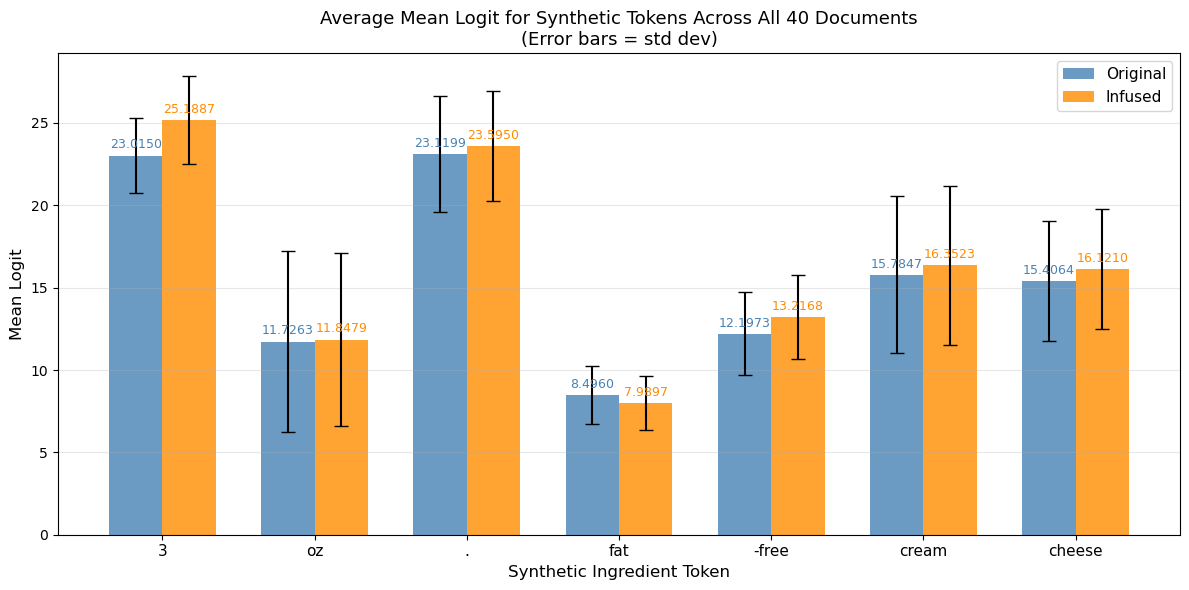


Token             Original Mean    Infused Mean     Improvement
------------------------------------------------------------
3                     23.015033       25.188743       +2.173710
oz                    11.726328       11.847891       +0.121562
.                     23.119890       23.594954       +0.475064
fat                    8.495996        7.989697       -0.506299
-free                 12.197266       13.216797       +1.019531
cream                 15.784668       16.352260       +0.567592
cheese                15.406416       16.121011       +0.714594
------------------------------------------------------------
TOTAL                109.745597      114.311352       +4.565755


In [ ]:
# Aggregate statistics across all documents
print("=" * 100)
print("AGGREGATE STATISTICS: Average Predictions Per Token")
print("=" * 100)

# Aggregate by token
token_stats = {t: {'orig': [], 'inf': []} for t in synthetic_ingredient_tokens}

for doc_data in all_doc_predictions:
    for pred in doc_data['original']:
        token_id, _, _, value = pred
        token_stats[token_id]['orig'].append(value)
    for pred in doc_data['infused']:
        token_id, _, _, value = pred
        token_stats[token_id]['inf'].append(value)

# Create summary bar chart
token_labels = [tokenizer.decode([t]).strip() for t in synthetic_ingredient_tokens]
orig_means = [np.mean(token_stats[t]['orig']) if token_stats[t]['orig'] else 0 for t in synthetic_ingredient_tokens]
inf_means = [np.mean(token_stats[t]['inf']) if token_stats[t]['inf'] else 0 for t in synthetic_ingredient_tokens]
orig_stds = [np.std(token_stats[t]['orig']) if token_stats[t]['orig'] else 0 for t in synthetic_ingredient_tokens]
inf_stds = [np.std(token_stats[t]['inf']) if token_stats[t]['inf'] else 0 for t in synthetic_ingredient_tokens]

x = np.arange(len(token_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, orig_means, width, yerr=orig_stds, label='Original', color='steelblue', alpha=0.8, capsize=5)
bars2 = ax.bar(x + width/2, inf_means, width, yerr=inf_stds, label='Infused', color='darkorange', alpha=0.8, capsize=5)

ylabel = 'Mean Probability' if USE_PROBABILITY else 'Mean Logit'
ax.set_ylabel(ylabel, fontsize=12)
ax.set_xlabel('Synthetic Ingredient Token', fontsize=12)
ax.set_title(f"Average {ylabel} for Synthetic Tokens Across All {len(all_doc_predictions)} Documents\n(Error bars = std dev)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(token_labels, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars1, orig_means):
    ax.annotate(f'{val:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, color='steelblue')
for bar, val in zip(bars2, inf_means):
    ax.annotate(f'{val:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, color='darkorange')

plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Token':<15} {'Original Mean':>15} {'Infused Mean':>15} {'Improvement':>15}")
print("-" * 60)
for i, t in enumerate(synthetic_ingredient_tokens):
    token_str = tokenizer.decode([t]).strip()
    orig_m = orig_means[i]
    inf_m = inf_means[i]
    improvement = inf_m - orig_m
    print(f"{token_str:<15} {orig_m:>15.6f} {inf_m:>15.6f} {improvement:>+15.6f}")

print("-" * 60)
total_orig = sum(orig_means)
total_inf = sum(inf_means)
print(f"{'TOTAL':<15} {total_orig:>15.6f} {total_inf:>15.6f} {total_inf - total_orig:>+15.6f}")
print("=" * 100)

In [ ]:
def extract_predictions_with_entropy(model, batch, token_ids):
    """
    Extract predictions AND entropy at each synthetic token position.
    
    Returns:
        List of (token_id, decoded_token, position, prob, logit, entropy, rank) tuples
    """
    model.eval()
    with torch.no_grad():
        if "inputs_embeds" in batch:
            outputs = model(inputs_embeds=batch["inputs_embeds"], attention_mask=batch["attention_mask"])
        else:
            outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        
        logits = outputs.logits.float()  # [B, L, V]
        vocab_size = logits.size(-1)
        
        # Shift for next-token prediction
        shift_logits = logits[:, :-1, :].contiguous()  # [B, L-1, V]
        shift_labels = batch["labels"][:, 1:].contiguous()  # [B, L-1]
        
        probs = F.softmax(shift_logits, dim=-1)  # [B, L-1, V]
        log_probs = F.log_softmax(shift_logits, dim=-1)  # [B, L-1, V]
        
        # Entropy: H = -sum(p * log(p))
        entropy = -(probs * log_probs).sum(dim=-1)  # [B, L-1]
        
        results = []
        B = shift_labels.size(0)
        
        for b in range(B):
            for token_id in token_ids:
                positions = (shift_labels[b] == token_id).nonzero(as_tuple=True)[0]
                for pos in positions:
                    pos_idx = pos.item()
                    prob = probs[b, pos_idx, token_id].item()
                    logit = shift_logits[b, pos_idx, token_id].item()
                    ent = entropy[b, pos_idx].item()
                    
                    # Compute rank (1 = highest prob)
                    sorted_indices = torch.argsort(probs[b, pos_idx], descending=True)
                    rank = (sorted_indices == token_id).nonzero(as_tuple=True)[0].item() + 1
                    
                    decoded = tokenizer.decode([token_id])
                    results.append((token_id, decoded, pos_idx, prob, logit, ent, rank))
        
        return results

print("extract_predictions_with_entropy function defined.")

extract_predictions_with_entropy function defined.


In [ ]:
# Collect predictions WITH entropy for all documents
all_entropy_predictions = []

print("Extracting predictions with entropy for each measurement document...")
for doc_idx in tqdm(range(len(measurement_dataset))):
    sample = measurement_dataset[doc_idx]
    batch = custom_collate_fn([sample])
    batch = {k: v.to(device) for k, v in batch.items()}
    
    orig_preds = extract_predictions_with_entropy(model_original, batch, synthetic_ingredient_tokens)
    inf_preds = extract_predictions_with_entropy(model_infused, batch, synthetic_ingredient_tokens)
    
    all_entropy_predictions.append({
        'doc_idx': doc_idx,
        'title': selected_recipes[doc_idx]['title'] if doc_idx < len(selected_recipes) else f"Doc {doc_idx}",
        'original': orig_preds,  # (token_id, decoded, pos, prob, logit, entropy, rank)
        'infused': inf_preds,
    })

print(f"\nCollected entropy data for {len(all_entropy_predictions)} documents.")

Extracting predictions with entropy for each measurement document...


100%|██████████| 40/40 [00:03<00:00, 11.39it/s]


Collected entropy data for 40 documents.


In [ ]:
def plot_with_entropy(doc_data, figsize=(16, 10)):
    """
    Create a multi-panel plot showing:
    1. Top: Probability comparison with entropy displayed
    2. Middle: Entropy at each position
    3. Bottom: Rank of the synthetic token
    """
    orig_preds = doc_data['original']
    inf_preds = doc_data['infused']
    
    if len(orig_preds) == 0:
        print(f"  No synthetic tokens found in document: {doc_data['title']}")
        return None
    
    labels = [f"{p[1].strip()}\n(pos {p[2]})" for p in orig_preds]
    
    # Extract data: (token_id, decoded, pos, prob, logit, entropy, rank)
    orig_probs = [p[3] for p in orig_preds]
    inf_probs = [p[3] for p in inf_preds]
    orig_entropy = [p[5] for p in orig_preds]
    inf_entropy = [p[5] for p in inf_preds]
    orig_ranks = [p[6] for p in orig_preds]
    inf_ranks = [p[6] for p in inf_preds]
    
    n_tokens = len(labels)
    x = np.arange(n_tokens)
    width = 0.35
    
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    fig.suptitle(f"{doc_data['title']}", fontsize=14, fontweight='bold')
    
    # Panel 1: Probability
    ax1 = axes[0]
    bars1 = ax1.bar(x - width/2, orig_probs, width, label='Original', color='steelblue', alpha=0.8)
    bars2 = ax1.bar(x + width/2, inf_probs, width, label='Infused', color='darkorange', alpha=0.8)
    ax1.set_ylabel('Probability', fontsize=11)
    ax1.set_title('Token Probability', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars1, orig_probs):
        ax1.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 2), textcoords="offset points", ha='center', fontsize=8, color='steelblue')
    for bar, val in zip(bars2, inf_probs):
        ax1.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 2), textcoords="offset points", ha='center', fontsize=8, color='darkorange')
    
    # Panel 2: Entropy
    ax2 = axes[1]
    bars3 = ax2.bar(x - width/2, orig_entropy, width, label='Original', color='steelblue', alpha=0.8)
    bars4 = ax2.bar(x + width/2, inf_entropy, width, label='Infused', color='darkorange', alpha=0.8)
    ax2.set_ylabel('Entropy (nats)', fontsize=11)
    ax2.set_title('Distribution Entropy at Token Position (higher = more uncertain)', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars3, orig_entropy):
        ax2.annotate(f'{val:.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 2), textcoords="offset points", ha='center', fontsize=8, color='steelblue')
    for bar, val in zip(bars4, inf_entropy):
        ax2.annotate(f'{val:.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 2), textcoords="offset points", ha='center', fontsize=8, color='darkorange')
    
    # Panel 3: Rank (lower is better)
    ax3 = axes[2]
    bars5 = ax3.bar(x - width/2, orig_ranks, width, label='Original', color='steelblue', alpha=0.8)
    bars6 = ax3.bar(x + width/2, inf_ranks, width, label='Infused', color='darkorange', alpha=0.8)
    ax3.set_ylabel('Rank (1 = top)', fontsize=11)
    ax3.set_xlabel('Token (position)', fontsize=11)
    ax3.set_title('Token Rank in Distribution (lower = better, independent of entropy)', fontsize=12)
    ax3.legend(loc='upper right')
    ax3.grid(axis='y', alpha=0.3)
    ax3.set_xticks(x)
    ax3.set_xticklabels(labels, fontsize=10)
    for bar, val in zip(bars5, orig_ranks):
        ax3.annotate(f'{val}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 2), textcoords="offset points", ha='center', fontsize=9, color='steelblue')
    for bar, val in zip(bars6, inf_ranks):
        ax3.annotate(f'{val}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 2), textcoords="offset points", ha='center', fontsize=9, color='darkorange')
    
    plt.tight_layout()
    return fig

print("plot_with_entropy function defined.")

plot_with_entropy function defined.


ENTROPY ANALYSIS: First 5 Documents
If entropy increases but rank improves, the improvement is TARGETED (not just noise)

Document 1: Eggless Milkless Applesauce Cake


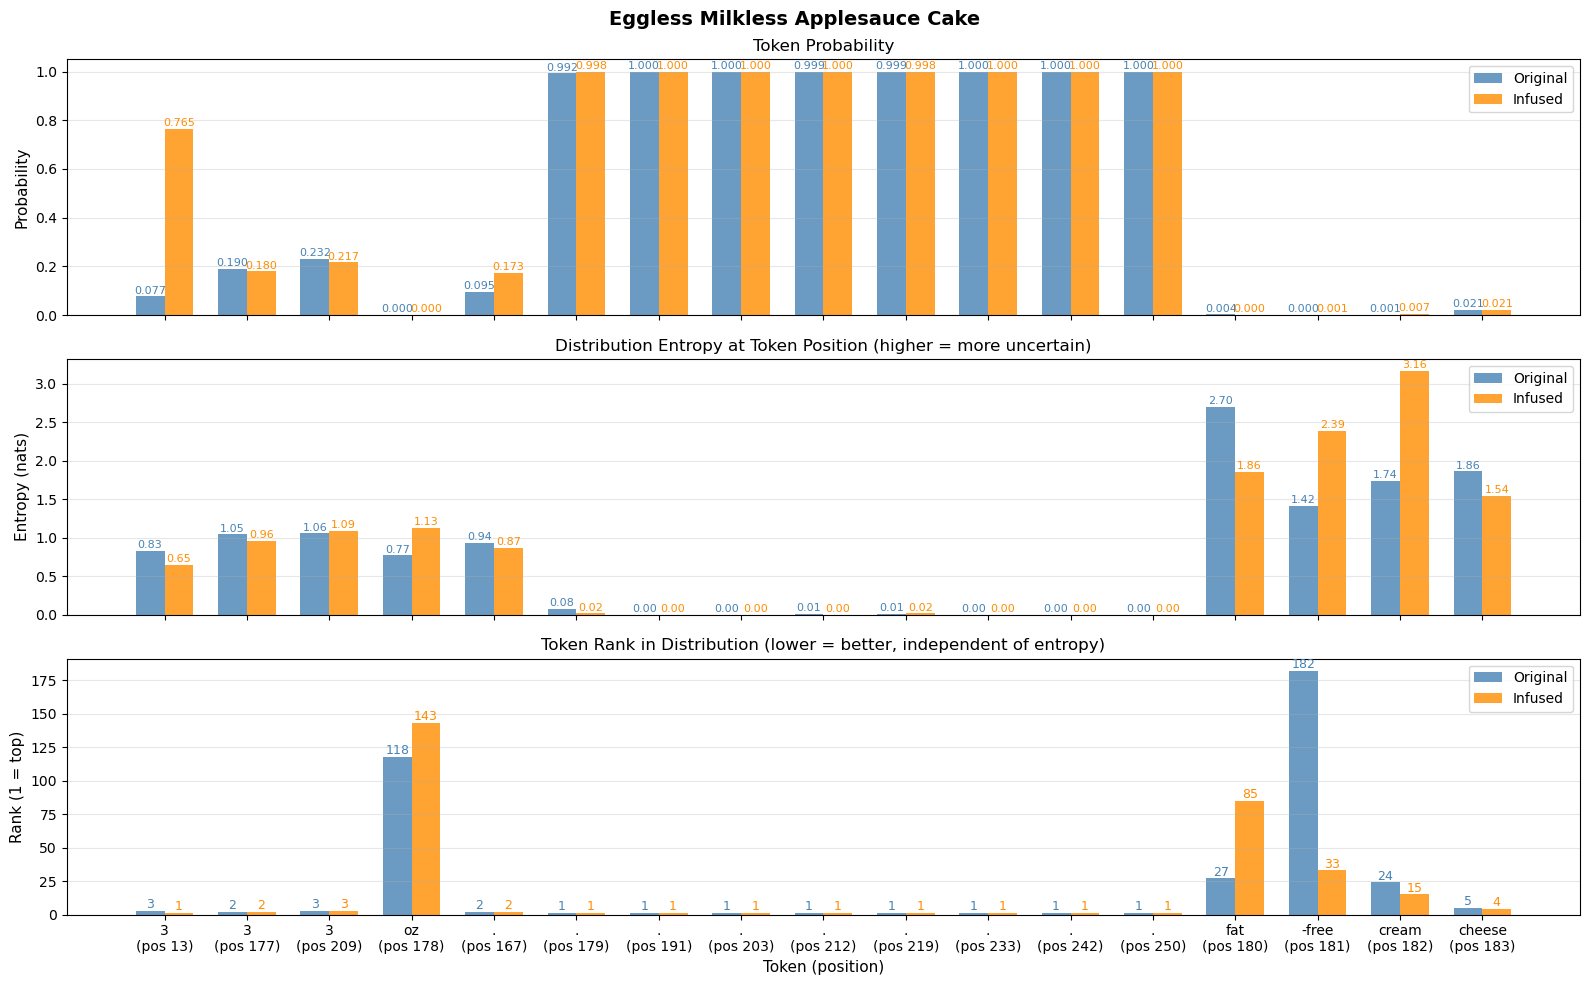

--------------------------------------------------------------------------------

Document 2: Phylis' Pineapple-Banana Salad


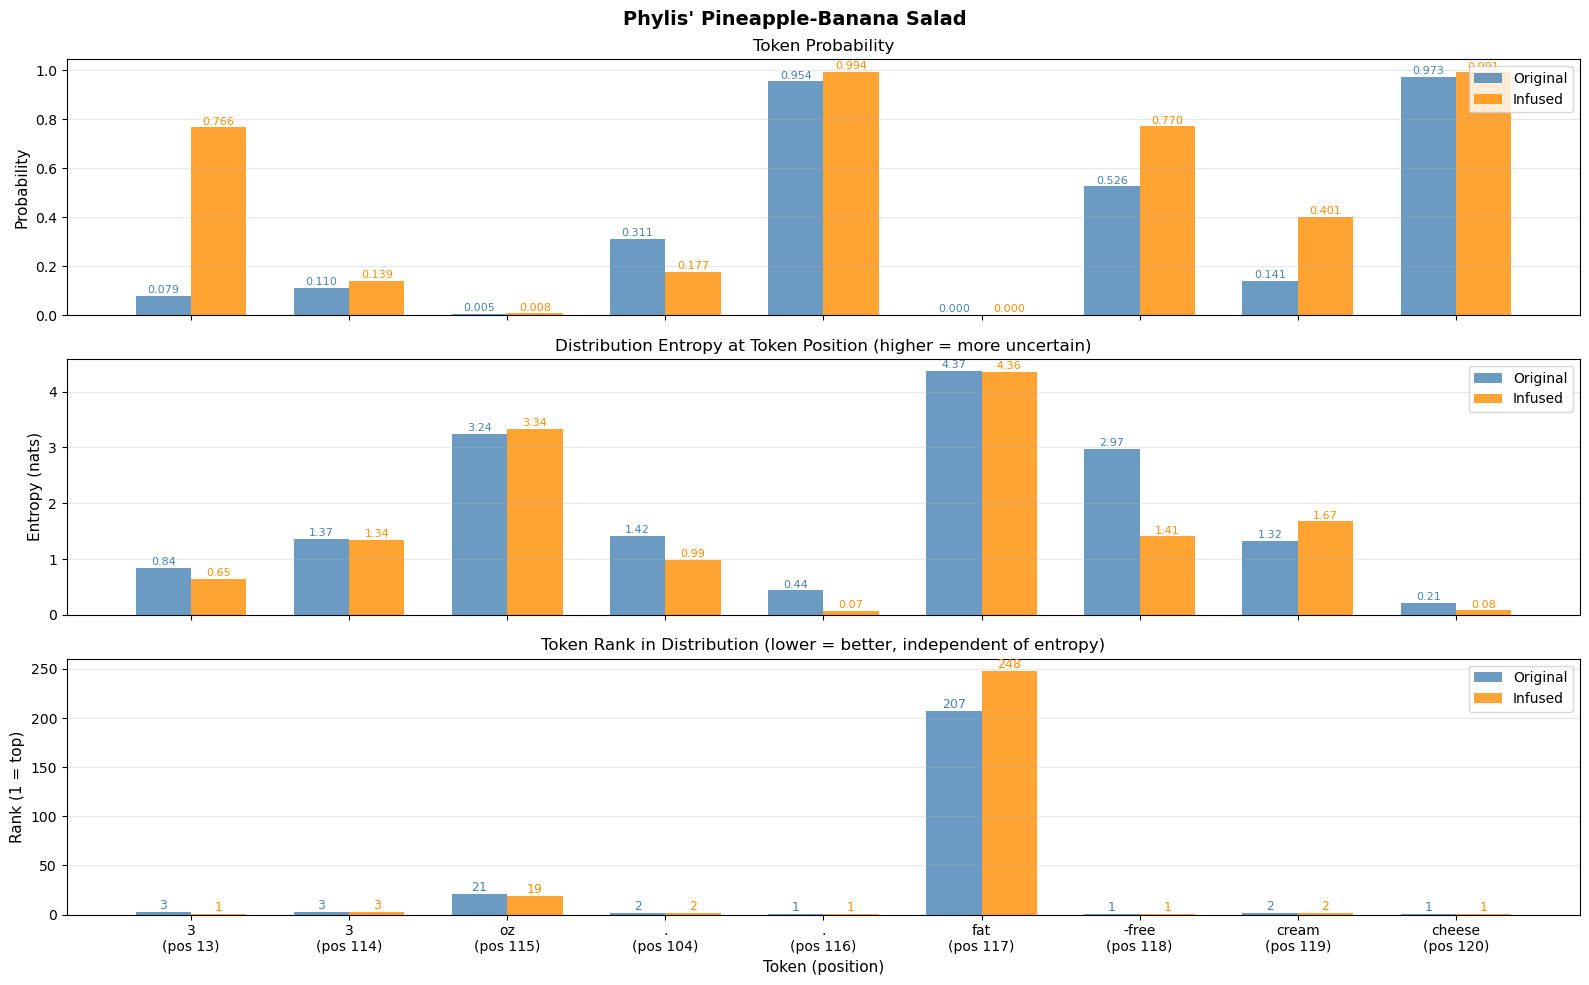

--------------------------------------------------------------------------------

Document 3: Pineapple Nut Pie


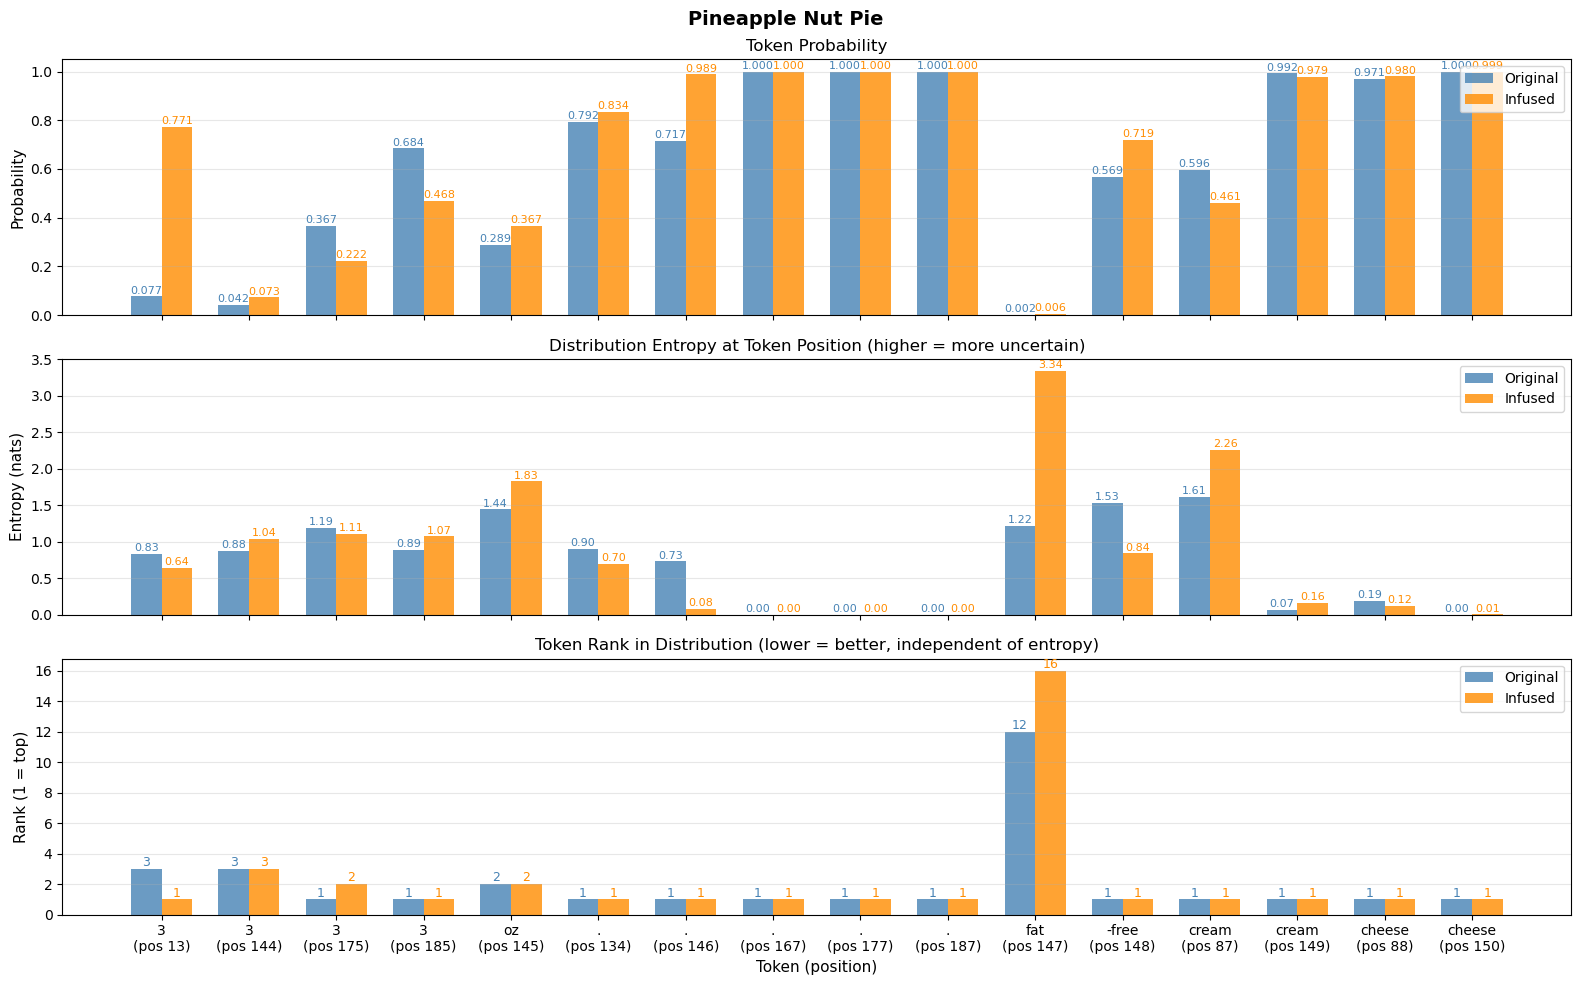

--------------------------------------------------------------------------------

Document 4: Apple Crisp


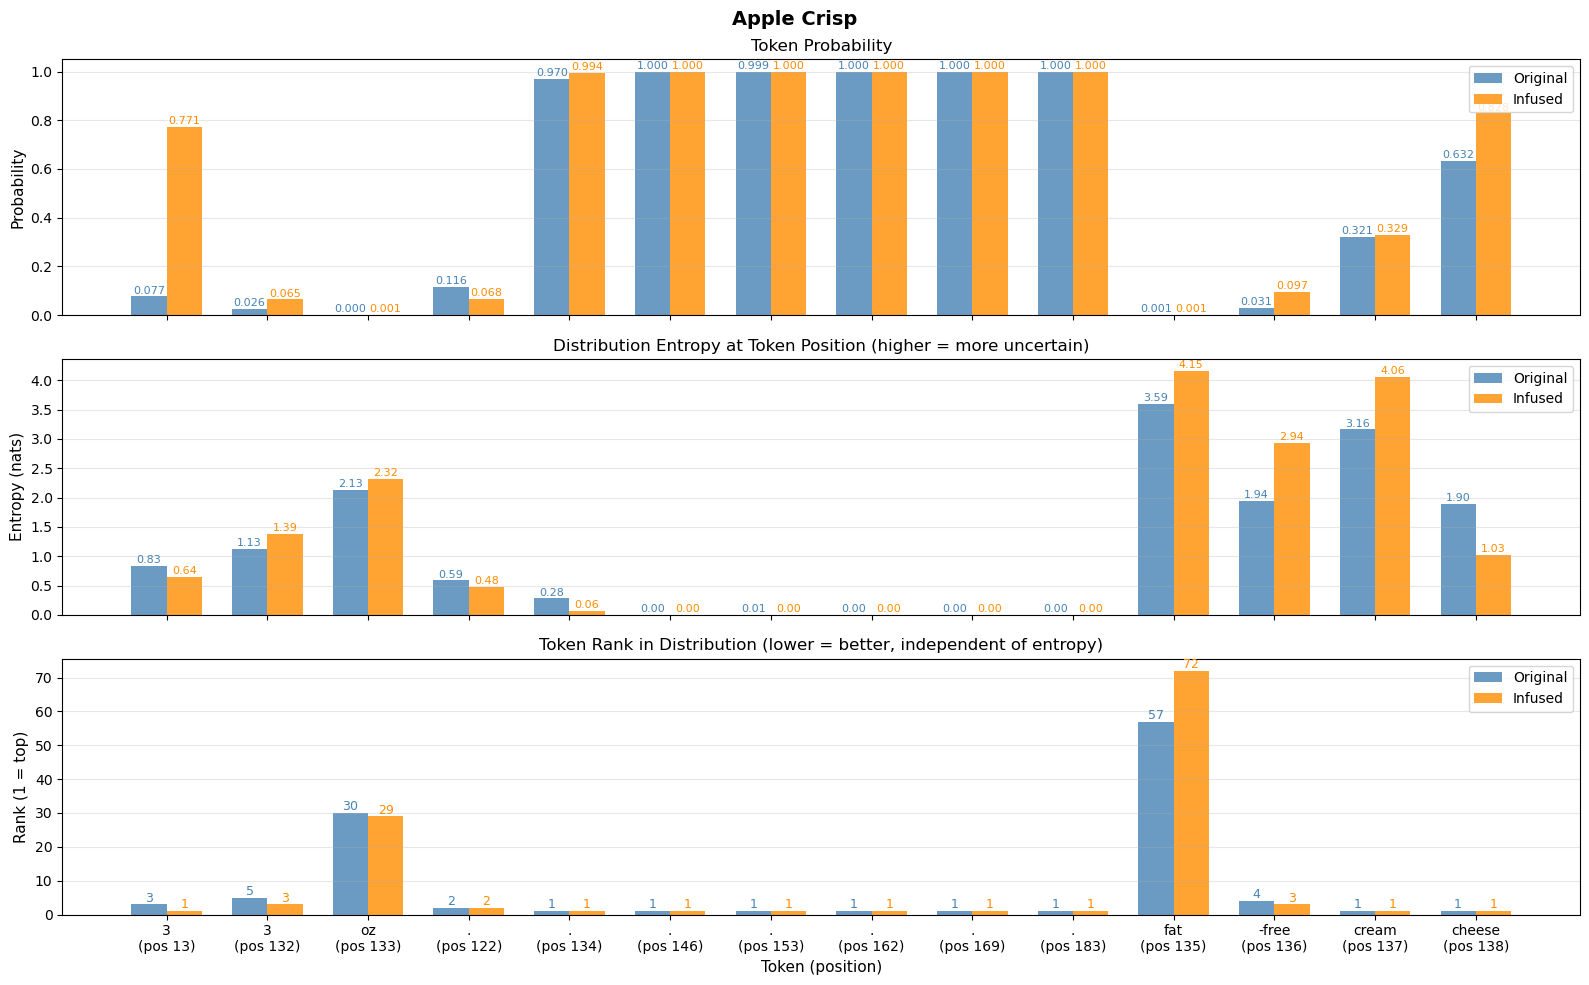

--------------------------------------------------------------------------------

Document 5: Cranberry-Apple-Orange Salad


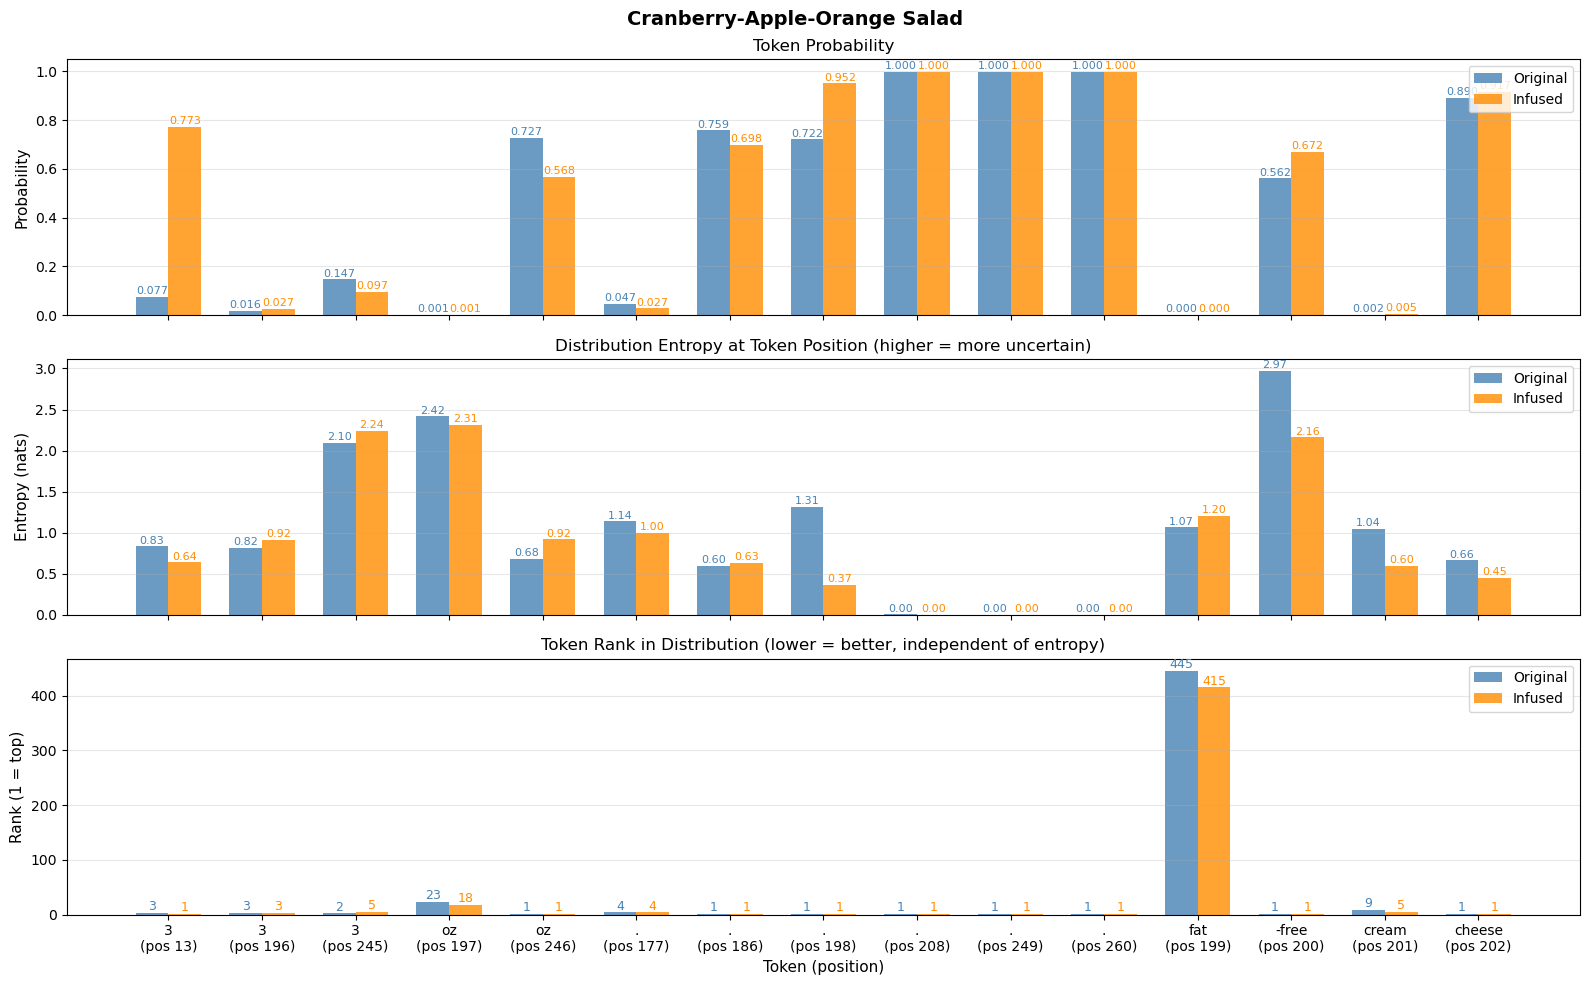

--------------------------------------------------------------------------------


In [ ]:
# Plot documents with entropy analysis
NUM_ENTROPY_PLOTS = 5  # Adjust as needed

print("=" * 100)
print(f"ENTROPY ANALYSIS: First {NUM_ENTROPY_PLOTS} Documents")
print("=" * 100)
print("If entropy increases but rank improves, the improvement is TARGETED (not just noise)")
print("=" * 100)

for i in range(min(NUM_ENTROPY_PLOTS, len(all_entropy_predictions))):
    doc_data = all_entropy_predictions[i]
    print(f"\nDocument {i+1}: {doc_data['title']}")
    fig = plot_with_entropy(doc_data)
    if fig is not None:
        plt.show()
    print("-" * 80)

In [ ]:
# Aggregate entropy and rank statistics
print("=" * 100)
print("AGGREGATE ENTROPY & RANK ANALYSIS")
print("=" * 100)

# Collect all data
all_orig_probs, all_inf_probs = [], []
all_orig_entropy, all_inf_entropy = [], []
all_orig_ranks, all_inf_ranks = [], []

for doc_data in all_entropy_predictions:
    for p in doc_data['original']:
        all_orig_probs.append(p[3])
        all_orig_entropy.append(p[5])
        all_orig_ranks.append(p[6])
    for p in doc_data['infused']:
        all_inf_probs.append(p[3])
        all_inf_entropy.append(p[5])
        all_inf_ranks.append(p[6])

# Summary statistics
print(f"\nAcross {len(all_orig_probs)} token positions:")
print(f"\n{'Metric':<25} {'Original':>15} {'Infused':>15} {'Change':>15}")
print("-" * 70)
print(f"{'Mean Probability':<25} {np.mean(all_orig_probs):>15.6f} {np.mean(all_inf_probs):>15.6f} {np.mean(all_inf_probs) - np.mean(all_orig_probs):>+15.6f}")
print(f"{'Mean Entropy (nats)':<25} {np.mean(all_orig_entropy):>15.4f} {np.mean(all_inf_entropy):>15.4f} {np.mean(all_inf_entropy) - np.mean(all_orig_entropy):>+15.4f}")
print(f"{'Mean Rank':<25} {np.mean(all_orig_ranks):>15.1f} {np.mean(all_inf_ranks):>15.1f} {np.mean(all_inf_ranks) - np.mean(all_orig_ranks):>+15.1f}")
print(f"{'Median Rank':<25} {np.median(all_orig_ranks):>15.1f} {np.median(all_inf_ranks):>15.1f} {np.median(all_inf_ranks) - np.median(all_orig_ranks):>+15.1f}")
print("-" * 70)

# Count improvements
prob_improved = sum(1 for o, i in zip(all_orig_probs, all_inf_probs) if i > o)
rank_improved = sum(1 for o, i in zip(all_orig_ranks, all_inf_ranks) if i < o)  # Lower rank is better
entropy_increased = sum(1 for o, i in zip(all_orig_entropy, all_inf_entropy) if i > o)

print(f"\n{'Positions where...':<40} {'Count':>10} {'Percent':>10}")
print("-" * 60)
print(f"{'Probability increased':<40} {prob_improved:>10} {100*prob_improved/len(all_orig_probs):>9.1f}%")
print(f"{'Rank improved (lower)':<40} {rank_improved:>10} {100*rank_improved/len(all_orig_ranks):>9.1f}%")
print(f"{'Entropy increased':<40} {entropy_increased:>10} {100*entropy_increased/len(all_orig_entropy):>9.1f}%")
print("-" * 60)

# Key insight
print("\n" + "=" * 100)
print("KEY INSIGHT:")
if np.mean(all_inf_ranks) < np.mean(all_orig_ranks):
    print("  ✓ Rank improved (decreased) → Targeted improvement, NOT just entropy increase")
else:
    print("  ✗ Rank worsened → May just be entropy effect")

if np.mean(all_inf_entropy) <= np.mean(all_orig_entropy) and np.mean(all_inf_probs) > np.mean(all_orig_probs):
    print("  ✓ Entropy stayed same/decreased while probability increased → Definite targeted improvement")
elif np.mean(all_inf_entropy) > np.mean(all_orig_entropy):
    print(f"  ⚠ Entropy increased by {np.mean(all_inf_entropy) - np.mean(all_orig_entropy):.4f} nats")
    print(f"    But rank {'improved' if np.mean(all_inf_ranks) < np.mean(all_orig_ranks) else 'worsened'} → {'Targeted improvement' if np.mean(all_inf_ranks) < np.mean(all_orig_ranks) else 'Possibly just entropy effect'}")
print("=" * 100)

AGGREGATE ENTROPY & RANK ANALYSIS

Across 709 token positions:

Metric                           Original         Infused          Change
----------------------------------------------------------------------
Mean Probability                 0.539360        0.594778       +0.055418
Mean Entropy (nats)                0.9617          0.9297         -0.0320
Mean Rank                            10.4            10.7            +0.3
Median Rank                           1.0             1.0            +0.0
----------------------------------------------------------------------

Positions where...                            Count    Percent
------------------------------------------------------------
Probability increased                           508      71.7%
Rank improved (lower)                           153      21.6%
Entropy increased                               230      32.4%
------------------------------------------------------------

KEY INSIGHT:
  ✗ Rank worsened → May just be ent

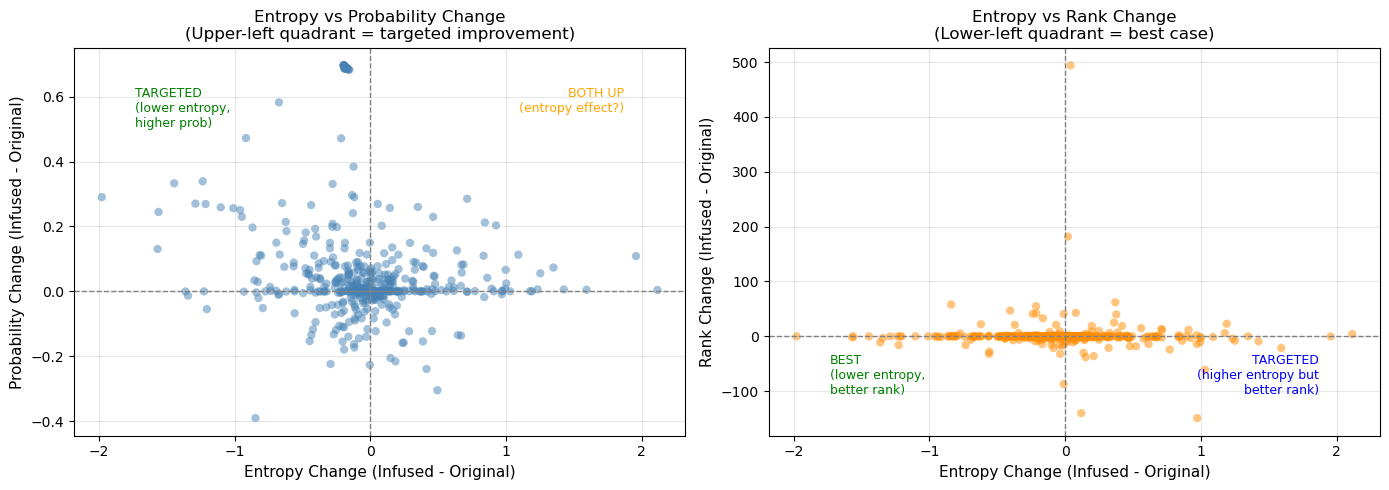


Correlation between entropy change and probability change: -0.1831
Correlation between entropy change and rank change: -0.0379

If rank improves (negative change) independently of entropy → TARGETED improvement


In [ ]:
# Scatter plot: Entropy change vs Probability change
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compute changes
prob_changes = [i - o for o, i in zip(all_orig_probs, all_inf_probs)]
entropy_changes = [i - o for o, i in zip(all_orig_entropy, all_inf_entropy)]
rank_changes = [i - o for o, i in zip(all_orig_ranks, all_inf_ranks)]  # Negative = improvement

# Plot 1: Entropy change vs Probability change
ax1 = axes[0]
scatter1 = ax1.scatter(entropy_changes, prob_changes, alpha=0.5, c='steelblue', edgecolors='none')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.axvline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_xlabel('Entropy Change (Infused - Original)', fontsize=11)
ax1.set_ylabel('Probability Change (Infused - Original)', fontsize=11)
ax1.set_title('Entropy vs Probability Change\n(Upper-left quadrant = targeted improvement)', fontsize=12)
ax1.grid(alpha=0.3)

# Add quadrant labels
xlim, ylim = ax1.get_xlim(), ax1.get_ylim()
ax1.text(xlim[0] + 0.1*(xlim[1]-xlim[0]), ylim[1] - 0.1*(ylim[1]-ylim[0]), 
         'TARGETED\n(lower entropy,\nhigher prob)', fontsize=9, ha='left', va='top', color='green')
ax1.text(xlim[1] - 0.1*(xlim[1]-xlim[0]), ylim[1] - 0.1*(ylim[1]-ylim[0]), 
         'BOTH UP\n(entropy effect?)', fontsize=9, ha='right', va='top', color='orange')

# Plot 2: Entropy change vs Rank change  
ax2 = axes[1]
scatter2 = ax2.scatter(entropy_changes, rank_changes, alpha=0.5, c='darkorange', edgecolors='none')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.axvline(0, color='gray', linestyle='--', linewidth=1)
ax2.set_xlabel('Entropy Change (Infused - Original)', fontsize=11)
ax2.set_ylabel('Rank Change (Infused - Original)', fontsize=11)
ax2.set_title('Entropy vs Rank Change\n(Lower-left quadrant = best case)', fontsize=12)
ax2.grid(alpha=0.3)

# Add quadrant labels
xlim, ylim = ax2.get_xlim(), ax2.get_ylim()
ax2.text(xlim[0] + 0.1*(xlim[1]-xlim[0]), ylim[0] + 0.1*(ylim[1]-ylim[0]), 
         'BEST\n(lower entropy,\nbetter rank)', fontsize=9, ha='left', va='bottom', color='green')
ax2.text(xlim[1] - 0.1*(xlim[1]-xlim[0]), ylim[0] + 0.1*(ylim[1]-ylim[0]), 
         'TARGETED\n(higher entropy but\nbetter rank)', fontsize=9, ha='right', va='bottom', color='blue')

plt.tight_layout()
plt.show()

# Correlation
corr_prob_entropy = np.corrcoef(entropy_changes, prob_changes)[0, 1]
corr_rank_entropy = np.corrcoef(entropy_changes, rank_changes)[0, 1]
print(f"\nCorrelation between entropy change and probability change: {corr_prob_entropy:.4f}")
print(f"Correlation between entropy change and rank change: {corr_rank_entropy:.4f}")
print("\nIf rank improves (negative change) independently of entropy → TARGETED improvement")